In [1]:
import pandas as pd
import shap
from IPython.core.pylabtools import figsize
from scipy.ndimage import label
from sklearn import preprocessing
from torch.nn.functional import threshold

C:\Users\ayoub\Desktop\Stage\Projet_I_E\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("../data/raw/import_export_synthetic.csv",sep=";");
df.head()

,reference,type_operation,categorie_produit,quantite,prix_unitaire,valeur_marchandise,devise,pays_origine,pays_destination,mode_transport,...,poids_kg,niveau_douane,priorite,date_operation,saison,duree_prevue_jours,date_livraison_prevue,duree_reelle_jours,date_livraison_reelle,retard
0,IMP-00001,IMPORT,PHARMACEUTIQUE,2056,238.75,490870.00,EUR,France,Maroc,MARITIME,...,3055.46,FAIBLE,NORMALE,2025-08-02,ETE,10,2025-08-12,9,2025-08-11,0
1,IMP-00002,IMPORT,MATERIAUX_CONSTRUCTION,909,456.47,414931.23,EUR,Turquie,Maroc,MARITIME,...,55431.04,ELEVE,NORMALE,2025-02-23,HIVER,16,2025-03-11,30,2025-03-25,1
2,IMP-00003,IMPORT,TEXTILE,3040,426.80,1297472.00,EUR,Portugal,Maroc,MARITIME,...,5626.45,MOYEN,URGENTE,2022-07-29,ETE,9,2022-08-07,7,2022-08-05,0
3,IMP-00004,IMPORT,TEXTILE,475,337.41,160269.75,EUR,Turquie,Maroc,AERIEN,...,1112.40,ELEVE,NORMALE,2024-01-11,HIVER,4,2024-01-15,4,2024-01-15,0
4,IMP-00005,IMPORT,PHARMACEUTIQUE,634,616.95,391146.30,USD,CorÃ©e du Sud,Maroc,MARITIME,...,243.28,MOYEN,URGENTE,2023-12-29,HIVER,30,2024-01-28,39,2024-02-06,1


In [3]:
df.shape

(20000, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   reference              20000 non-null  str    
 1   type_operation         20000 non-null  str    
 2   categorie_produit      20000 non-null  str    
 3   quantite               20000 non-null  int64  
 4   prix_unitaire          20000 non-null  float64
 5   valeur_marchandise     20000 non-null  float64
 6   devise                 20000 non-null  str    
 7   pays_origine           20000 non-null  str    
 8   pays_destination       20000 non-null  str    
 9   mode_transport         20000 non-null  str    
 10  distance_km            20000 non-null  int64  
 11  poids_kg               20000 non-null  float64
 12  niveau_douane          20000 non-null  str    
 13  priorite               20000 non-null  str    
 14  date_operation         20000 non-null  str    
 15  saison       

In [5]:
df["date_operation"] = pd.to_datetime(df["date_operation"])
df["date_livraison_prevue"] = pd.to_datetime(df["date_livraison_prevue"])
df["date_livraison_reelle"] = pd.to_datetime(df["date_livraison_reelle"])

In [6]:
df[
    [
        "date_operation",
        "date_livraison_prevue",
        "date_livraison_reelle"
    ]
].dtypes

date_operation           datetime64[us]
date_livraison_prevue    datetime64[us]
date_livraison_reelle    datetime64[us]
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   reference              20000 non-null  str           
 1   type_operation         20000 non-null  str           
 2   categorie_produit      20000 non-null  str           
 3   quantite               20000 non-null  int64         
 4   prix_unitaire          20000 non-null  float64       
 5   valeur_marchandise     20000 non-null  float64       
 6   devise                 20000 non-null  str           
 7   pays_origine           20000 non-null  str           
 8   pays_destination       20000 non-null  str           
 9   mode_transport         20000 non-null  str           
 10  distance_km            20000 non-null  int64         
 11  poids_kg               20000 non-null  float64       
 12  niveau_douane          20000 non-null  str           
 13  priorite    

In [8]:
df.isnull().sum()

reference                0
type_operation           0
categorie_produit        0
quantite                 0
prix_unitaire            0
valeur_marchandise       0
devise                   0
pays_origine             0
pays_destination         0
mode_transport           0
distance_km              0
poids_kg                 0
niveau_douane            0
priorite                 0
date_operation           0
saison                   0
duree_prevue_jours       0
date_livraison_prevue    0
duree_reelle_jours       0
date_livraison_reelle    0
retard                   0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,quantite,prix_unitaire,valeur_marchandise,distance_km,poids_kg,date_operation,duree_prevue_jours,date_livraison_prevue,duree_reelle_jours,date_livraison_reelle,retard
count,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000,20000.000000,20000,20000.000000,20000,20000.000000
mean,2055.182550,7701.024509,1.487539e+06,4769.643850,24171.175857,2023-12-31 15:57:48.960000,12.113450,2024-01-12 18:41:11.040000,14.268400,2024-01-14 22:24:18.720000,0.364000
min,1.000000,5.010000,1.451120e+03,855.000000,2.330000,2022-01-01 00:00:00,2.000000,2022-01-05 00:00:00,1.000000,2022-01-05 00:00:00,0.000000
25%,315.000000,169.362500,3.098025e+05,2219.000000,2305.820000,2022-12-30 00:00:00,5.000000,2023-01-12 00:00:00,4.000000,2023-01-16 00:00:00,0.000000
50%,968.000000,565.745000,8.268593e+05,2798.000000,7913.700000,2024-01-01 00:00:00,9.000000,2024-01-14 00:00:00,10.000000,2024-01-18 00:00:00,0.000000
75%,3227.250000,4287.345000,1.879876e+06,6329.000000,34253.292500,2025-01-01 00:00:00,19.000000,2025-01-14 00:00:00,23.000000,2025-01-18 00:00:00,1.000000
max,9997.000000,99941.920000,1.467498e+07,12074.000000,199108.480000,2025-12-31 00:00:00,34.000000,2026-01-31 00:00:00,50.000000,2026-02-14 00:00:00,1.000000
std,2360.663747,18118.821143,1.860286e+06,3467.898198,33739.617705,NaN,8.771689,NaN,12.239398,NaN,0.481161


In [11]:
df.groupby("categorie_produit")["poids_kg"].agg(
    ["mean","median","max"]
).sort_values("max",ascending=False)

,mean,median,max
categorie_produit,,,
MACHINES,50842.011789,40215.140,199108.48
MATERIAUX_CONSTRUCTION,55541.880538,44093.940,194871.59
AGRICOLE,53206.951088,41553.800,194429.27
AUTOMOBILE,25718.425020,19080.745,98759.54
ALIMENTAIRE,26703.107528,20830.040,97398.03
EQUIPEMENT_MEDICAL,18670.747642,14328.020,73171.11
TEXTILE,3898.741055,2936.185,14102.32
PHARMACEUTIQUE,2576.209711,1960.990,9975.73
COSMETIQUE,2626.746016,2043.415,9829.75


In [12]:
df["retard"].value_counts()

retard
0    12720
1     7280
Name: count, dtype: int64

In [13]:
df["retard"].value_counts(normalize=True) * 100

retard
0    63.6
1    36.4
Name: proportion, dtype: float64

In [14]:
incoherences = df[
    ((df["retard"] == 1) & (df["duree_reelle_jours"] <= df["duree_prevue_jours"])) |
    ((df["retard"] == 0 ) & (df["duree_reelle_jours"] > df["duree_prevue_jours"]))
]
len(incoherences)

0

In [15]:
categorical_columns = [
    "type_operation",
    "categorie_produit",
    "devise",
    "mode_transport",
    "niveau_douane",
    "priorite",
    "saison"
]


for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


type_operation:
type_operation
EXPORT    10078
IMPORT     9922
Name: count, dtype: int64

categorie_produit:
categorie_produit
MATERIAUX_CONSTRUCTION    2044
PHARMACEUTIQUE            2039
ALIMENTAIRE               2027
EQUIPEMENT_MEDICAL        2014
COSMETIQUE                2008
AUTOMOBILE                1994
AGRICOLE                  1976
TEXTILE                   1972
ELECTRONIQUE              1970
MACHINES                  1956
Name: count, dtype: int64

devise:
devise
EUR    8885
USD    7641
MAD    3474
Name: count, dtype: int64

mode_transport:
mode_transport
MARITIME    10557
ROUTIER      6704
AERIEN       2739
Name: count, dtype: int64

niveau_douane:
niveau_douane
MOYEN     11057
FAIBLE     4926
ELEVE      4017
Name: count, dtype: int64

priorite:
priorite
NORMALE    15970
URGENTE     4030
Name: count, dtype: int64

saison:
saison
PRINTEMPS    5022
HIVER        5004
ETE          4995
AUTOMNE      4979
Name: count, dtype: int64


In [16]:
invalid_routes = df[
    ((df["type_operation"] == "IMPORT") & (df["pays_destination"] != "Maroc")) |
    ((df["type_operation"] == "EXPORT") & (df["pays_origine"] != "Maroc"))
]

len(invalid_routes)

0

In [17]:
numeric_columns = [
    "quantite",
    "prix_unitaire",
    "valeur_marchandise",
    "distance_km",
    "poids_kg",
    "duree_prevue_jours",
    "duree_reelle_jours"
]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
quantite,20000.0,2.055183e+03,2.360664e+03,1.00,315.0000,968.000,3.227250e+03,9997.00
prix_unitaire,20000.0,7.701025e+03,1.811882e+04,5.01,169.3625,565.745,4.287345e+03,99941.92
valeur_marchandise,20000.0,1.487539e+06,1.860286e+06,1451.12,309802.5125,826859.310,1.879876e+06,14674976.42
distance_km,20000.0,4.769644e+03,3.467898e+03,855.00,2219.0000,2798.000,6.329000e+03,12074.00
poids_kg,20000.0,2.417118e+04,3.373962e+04,2.33,2305.8200,7913.700,3.425329e+04,199108.48
duree_prevue_jours,20000.0,1.211345e+01,8.771689e+00,2.00,5.0000,9.000,1.900000e+01,34.00
duree_reelle_jours,20000.0,1.426840e+01,1.223940e+01,1.00,4.0000,10.000,2.300000e+01,50.00


In [18]:
df.to_csv(
    "../data/processed/import_export_synthetic.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

In [19]:
import matplotlib.pyplot as plt

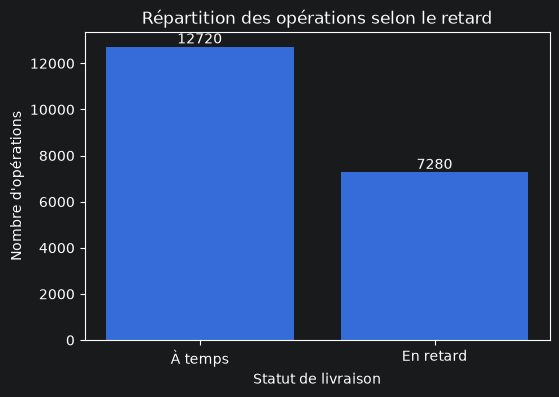

In [20]:
retard_counts = df["retard"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(
    ["À temps","En retard"],
    retard_counts.values
)

ax.set_title("Répartition des opérations selon le retard")
ax.set_xlabel("Statut de livraison")
ax.set_ylabel("Nombre d'opérations")

ax.bar_label(bars)

plt.show()

In [21]:
retard_transport = pd.crosstab(
    df["mode_transport"],
    df["retard"],
    normalize="index"
) * 100
retard_transport

retard,0,1
mode_transport,,
AERIEN,93.355239,6.644761
MARITIME,38.410533,61.589467
ROUTIER,91.109785,8.890215


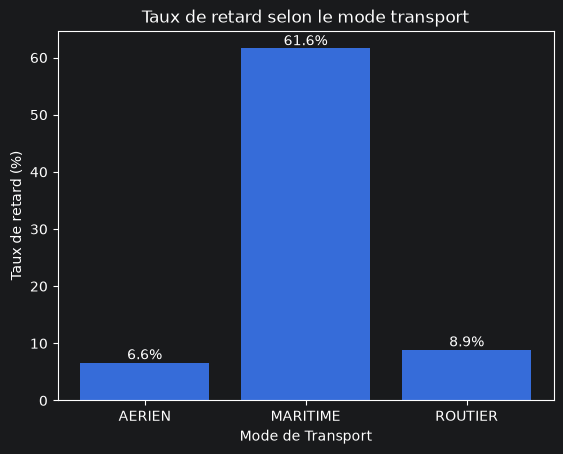

In [22]:
retard_par_transport = retard_transport[1]
bars = plt.bar(
    retard_par_transport.index,
    retard_par_transport.values
)
plt.title("Taux de retard selon le mode transport")
plt.xlabel("Mode de Transport")
plt.ylabel("Taux de retard (%)")
plt.bar_label(
    bars,
    fmt="%.1f%%"
)
plt.show()

In [23]:
y = df["retard"]

In [24]:
features = [
    "type_operation",
    "categorie_produit",
    "quantite",
    "prix_unitaire",
    "devise",
    "pays_origine",
    "pays_destination",
    "mode_transport",
    "distance_km",
    "poids_kg",
    "niveau_douane",
    "priorite",
    "saison",
    "duree_prevue_jours"
]

X = df[features]

In [25]:
print("X :", X.shape)
print("y :", y.shape)

X : (20000, 14)
y : (20000,)


In [26]:
numerical_features = [
    "quantite",
    "prix_unitaire",
    "distance_km",
    "poids_kg",
    "duree_prevue_jours"
]

categorical_features = [
    "type_operation",
    "categorie_produit",
    "devise",
    "pays_origine",
    "pays_destination",
    "mode_transport",
    "niveau_douane",
    "priorite",
    "saison"
]

print("Variables numériques :", len(numerical_features))
print("Variables catégorielles :", len(categorical_features))
print("Total :", len(numerical_features) + len(categorical_features))

Variables numériques : 5
Variables catégorielles : 9
Total : 14


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [28]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16000, 14)
X_test: (4000, 14)
y_train: (16000,)
y_test: (4000,)


In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [31]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [32]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(16000, 64)
(4000, 64)


In [33]:
feature_name = preprocessor.get_feature_names_out()
feature_name

array(['num__quantite', 'num__prix_unitaire', 'num__distance_km',
       'num__poids_kg', 'num__duree_prevue_jours',
       'cat__type_operation_EXPORT', 'cat__type_operation_IMPORT',
       'cat__categorie_produit_AGRICOLE',
       'cat__categorie_produit_ALIMENTAIRE',
       'cat__categorie_produit_AUTOMOBILE',
       'cat__categorie_produit_COSMETIQUE',
       'cat__categorie_produit_ELECTRONIQUE',
       'cat__categorie_produit_EQUIPEMENT_MEDICAL',
       'cat__categorie_produit_MACHINES',
       'cat__categorie_produit_MATERIAUX_CONSTRUCTION',
       'cat__categorie_produit_PHARMACEUTIQUE',
       'cat__categorie_produit_TEXTILE', 'cat__devise_EUR',
       'cat__devise_MAD', 'cat__devise_USD',
       'cat__pays_origine_Allemagne', 'cat__pays_origine_Belgique',
       'cat__pays_origine_Canada', 'cat__pays_origine_Chine',
       'cat__pays_origine_CorÃ©e du Sud', 'cat__pays_origine_Espagne',
       'cat__pays_origine_France', 'cat__pays_origine_Italie',
       'cat__pays_origine_Ja

In [34]:
print(len(feature_name))

64


In [35]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_processed, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [36]:
y_pred = model.predict(X_test_processed)

In [37]:
print(y_pred[:10])

[1 1 1 1 1 0 0 0 0 0]


In [38]:
import numpy as np

In [39]:
values , counts  = np.unique(y_pred,return_counts=True)
print(values)
print(counts)

[0 1]
[2565 1435]


In [40]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score , recall_score , f1_score , classification_report , roc_auc_score
cm = confusion_matrix(y_test, y_pred)
cm
accuracy = accuracy_score(y_test, y_pred)
accuracy
precision = precision_score(y_test, y_pred)
precision
recal = recall_score(y_test, y_pred)
recal
f1 = f1_score(y_test, y_pred)
f1
print(classification_report(y_test, y_pred))
roc_auc = roc_auc_score(y_test, y_pred)
roc_auc

              precision    recall  f1-score   support

           0       0.92      0.93      0.93      2544
           1       0.88      0.87      0.87      1456

    accuracy                           0.91      4000
   macro avg       0.90      0.90      0.90      4000
weighted avg       0.91      0.91      0.91      4000



0.8988376010781671

In [41]:
from sklearn.ensemble import RandomForestClassifier

In [42]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

In [43]:
model_rf.fit(X_train_processed,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [44]:
y_pred_rf = model_rf.predict(X_test_processed)
import numpy as np
values , counts = np.unique(y_pred_rf,return_counts=True)
print(values)
print(counts)

[0 1]
[2505 1495]


In [45]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_rf

array([[2335,  209],
       [ 170, 1286]])

In [46]:
recall_rf = recall_score(y_test, y_pred_rf)
recall_rf

0.8832417582417582

In [47]:
from xgboost import XGBClassifier

In [48]:
model_xgb = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss",
)
model_xgb.fit(
    X_train_processed,
    y_train,
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [49]:
import numpy as np
y_pred_xg = model_xgb.predict(X_test_processed)
values , counts = np.unique(y_pred_xg,return_counts=True)
print(values)
print(counts)

[0 1]
[2586 1414]


In [50]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, recall_score, precision_score,roc_auc_score
cm_xg = confusion_matrix(y_test, y_pred_xg)
cm_xg
accuracy_xg = accuracy_score(y_test, y_pred_xg)
f1_score_xg = f1_score(y_test, y_pred_xg)
recall_score_xg = recall_score(y_test, y_pred_xg)
precision_score_xg = precision_score(y_test, y_pred_xg)
y_proba_xg = model_xgb.predict_proba(X_test_processed)[:, 1]
roc_auc_xg = roc_auc_score(y_test, y_proba_xg)
print(accuracy_xg)
print(f1_score_xg)
print(recall_score_xg)
print(precision_score_xg)
print(roc_auc_xg)

0.912
0.8773519163763066
0.8646978021978022
0.8903818953323904
0.9734237853341626


In [51]:
from sklearn.metrics import roc_curve
import matplotlib.pylab as plt

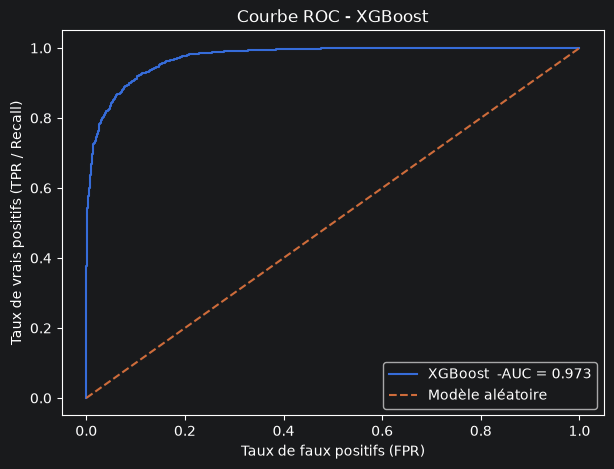

In [52]:
fpr , tpr , thresholds = roc_curve(y_test, y_proba_xg)
plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"XGBoost  -AUC = {roc_auc_xg:.3f}"
)
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Modèle aléatoire"
)
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR / Recall)")
plt.title("Courbe ROC - XGBoost")
plt.legend()
plt.show()

In [53]:
features_names = preprocessor.get_feature_names_out()
print(len(features_names))
print(features_names)

64
['num__quantite' 'num__prix_unitaire' 'num__distance_km' 'num__poids_kg'
 'num__duree_prevue_jours' 'cat__type_operation_EXPORT'
 'cat__type_operation_IMPORT' 'cat__categorie_produit_AGRICOLE'
 'cat__categorie_produit_ALIMENTAIRE' 'cat__categorie_produit_AUTOMOBILE'
 'cat__categorie_produit_COSMETIQUE' 'cat__categorie_produit_ELECTRONIQUE'
 'cat__categorie_produit_EQUIPEMENT_MEDICAL'
 'cat__categorie_produit_MACHINES'
 'cat__categorie_produit_MATERIAUX_CONSTRUCTION'
 'cat__categorie_produit_PHARMACEUTIQUE' 'cat__categorie_produit_TEXTILE'
 'cat__devise_EUR' 'cat__devise_MAD' 'cat__devise_USD'
 'cat__pays_origine_Allemagne' 'cat__pays_origine_Belgique'
 'cat__pays_origine_Canada' 'cat__pays_origine_Chine'
 'cat__pays_origine_CorÃ©e du Sud' 'cat__pays_origine_Espagne'
 'cat__pays_origine_France' 'cat__pays_origine_Italie'
 'cat__pays_origine_Japon' 'cat__pays_origine_Maroc'
 'cat__pays_origine_Pays-Bas' 'cat__pays_origine_Portugal'
 'cat__pays_origine_Royaume-Uni' 'cat__pays_origine_T

In [54]:
importances = model_xgb.feature_importances_
print(len(importances))
print(importances)

64
[0.00564757 0.00581636 0.01363323 0.01208879 0.19994281 0.00381144
 0.         0.01510264 0.01566656 0.00437025 0.00956689 0.00729271
 0.0075354  0.03377067 0.00611626 0.00947023 0.01600498 0.00461547
 0.00557332 0.0100025  0.0065667  0.00447651 0.00830984 0.00613773
 0.0119975  0.00607678 0.0055159  0.00496601 0.00735151 0.
 0.00342825 0.00485906 0.00499109 0.00581737 0.00539941 0.00637618
 0.00344557 0.00799679 0.01132443 0.00436542 0.00819004 0.00459553
 0.00481657 0.00465384 0.01001142 0.         0.00325599 0.00287954
 0.00653089 0.00806275 0.00826203 0.00437178 0.01195347 0.05689676
 0.00927093 0.14006118 0.04118731 0.00330281 0.03649415 0.
 0.00572599 0.01208548 0.08706811 0.02489329]


In [55]:
importance_df = pd.DataFrame({
    "Variable" : features_names,
    "Importance" : importances
})
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)
importance_df.head(10)

,Variable,Importance
4,num__duree_prevue_jours,0.199943
55,cat__niveau_douane_ELEVE,0.140061
62,cat__saison_HIVER,0.087068
53,cat__mode_transport_MARITIME,0.056897
56,cat__niveau_douane_FAIBLE,0.041187
58,cat__priorite_NORMALE,0.036494
13,cat__categorie_produit_MACHINES,0.033771
63,cat__saison_PRINTEMPS,0.024893
16,cat__categorie_produit_TEXTILE,0.016005
8,cat__categorie_produit_ALIMENTAIRE,0.015667


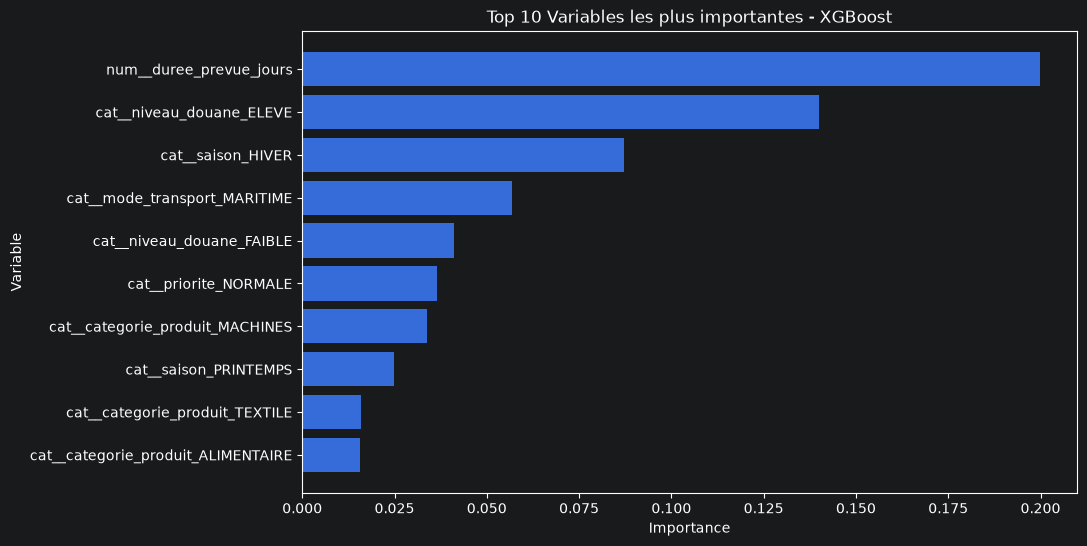

In [56]:
top10 = importance_df.head(10)
plt.figure(figsize=(10,6))
plt.barh(
    top10["Variable"][::-1],
    top10["Importance"][::-1],
)
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.title("Top 10 Variables les plus importantes - XGBoost")
plt.show()

In [57]:
import shap
explainer = shap.TreeExplainer(model_xgb)

In [58]:
shapes_values = explainer(X_test_processed)
print(shapes_values.shape)

(4000, 64)


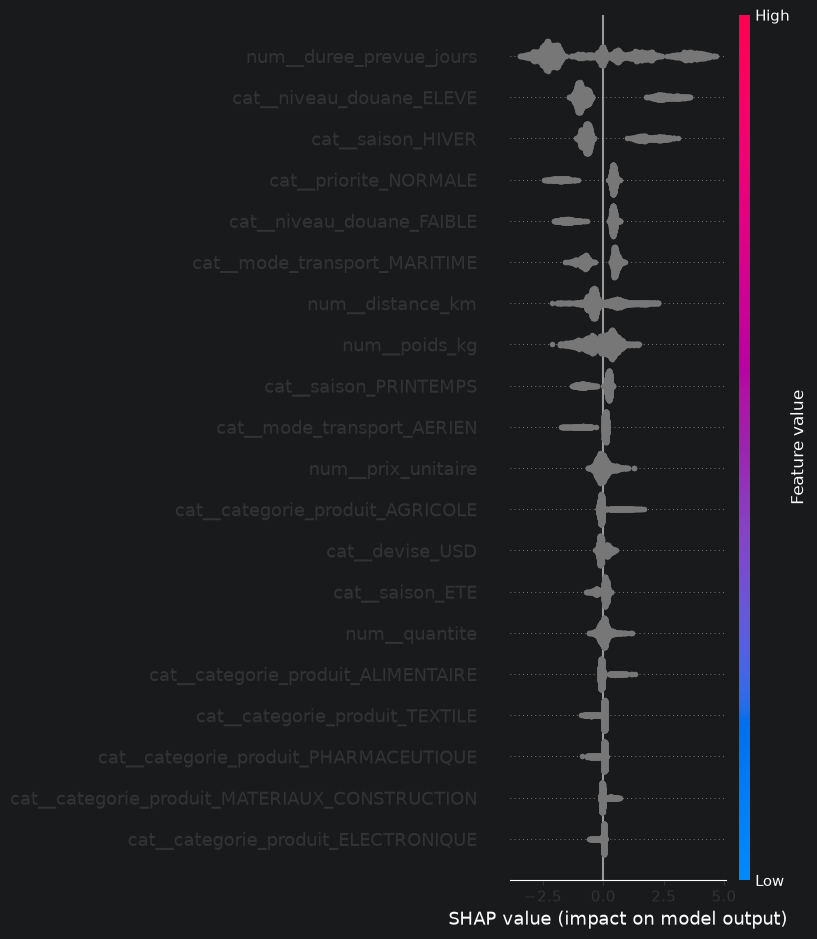

In [59]:
shap.summary_plot(
    shapes_values,
    X_test_processed,
    feature_names=features_names
)

In [60]:
from scipy import sparse
if sparse.issparse(X_test_processed):
    X_test_shape = pd.DataFrame(
        X_test_processed.toarray(),
        columns = features_names
    )
else:
    X_test_shape = pd.DataFrame(
        X_test_processed,
        columns = features_names
    )

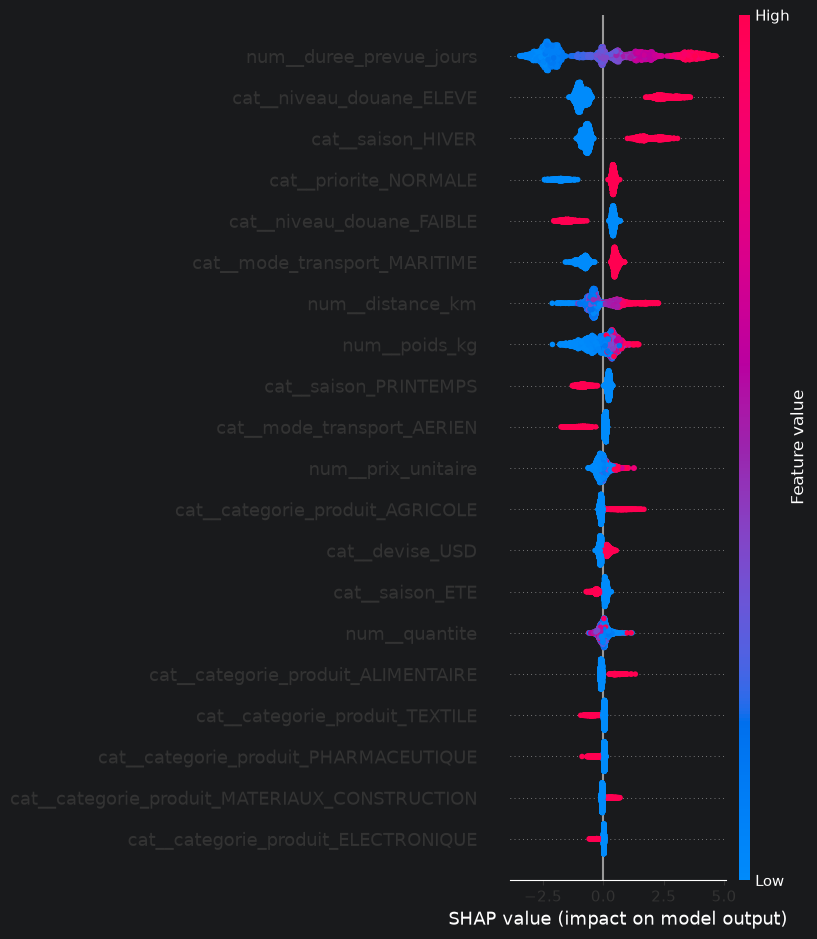

In [63]:
shap.summary_plot(
    shapes_values.values,
    X_test_shape,
    feature_names=features_names
)

Index choisi : , 0


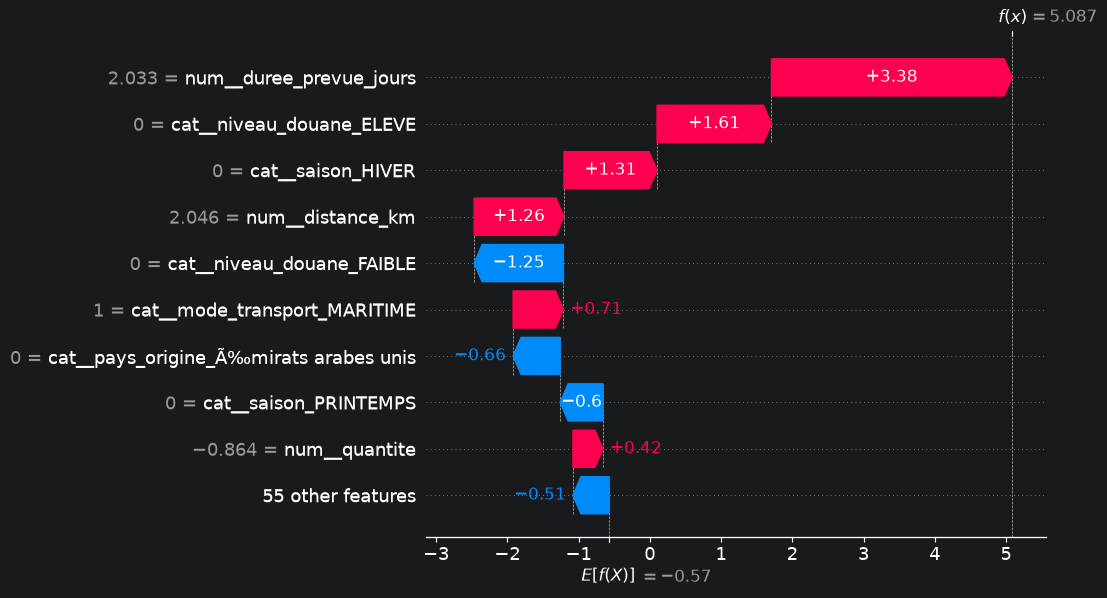

In [66]:
idx = np.where(y_pred_xg == 1)[0][0]
print("Index choisi : ,",idx)
shapes_values_named = explainer(X_test_shape)
shap.plots.waterfall(
    shapes_values_named[idx],
    max_display=10
)

In [67]:
import joblib
from pathlib import Path

In [68]:
model_dir = Path("../ml/models")
model_dir.mkdir(parents=True, exist_ok=True)
bundle = {
    "model" : model_xgb,
    "preprocessor" : preprocessor,
    "features" : features
}

joblib.dump(
    bundle,
    model_dir / "retard_xgboost.joblib"
)

print((model_dir / "retard_xgboost.joblib").exists())

True


In [74]:
loaded_bundle = joblib.load("../ml/models/retard_xgboost.joblib")
print(loaded_bundle.keys())
loaded_model = loaded_bundle["model"]
loaded_preprocessor = loaded_bundle["preprocessor"]
loaded_features = loaded_bundle["features"]
print(type(loaded_model))
print(type(loaded_preprocessor))
print(loaded_features)

dict_keys(['model', 'preprocessor', 'features'])
<class 'xgboost.sklearn.XGBClassifier'>
<class 'sklearn.compose._column_transformer.ColumnTransformer'>
['type_operation', 'categorie_produit', 'quantite', 'prix_unitaire', 'devise', 'pays_origine', 'pays_destination', 'mode_transport', 'distance_km', 'poids_kg', 'niveau_douane', 'priorite', 'saison', 'duree_prevue_jours']


In [75]:
nouvelle_operation = pd.DataFrame([{
    "type_operation": "IMPORT",
    "categorie_produit": "ELECTRONIQUE",
    "quantite": 800,
    "prix_unitaire": 1200,
    "devise": "EUR",
    "pays_origine": "France",
    "pays_destination": "Maroc",
    "mode_transport": "MARITIME",
    "distance_km": 2200,
    "poids_kg": 6000,
    "niveau_douane": "ELEVE",
    "priorite": "NORMALE",
    "saison": "HIVER",
    "duree_prevue_jours": 12
}])

nouvelle_operation

,type_operation,categorie_produit,quantite,prix_unitaire,devise,pays_origine,pays_destination,mode_transport,distance_km,poids_kg,niveau_douane,priorite,saison,duree_prevue_jours
0,IMPORT,ELECTRONIQUE,800,1200,EUR,France,Maroc,MARITIME,2200,6000,ELEVE,NORMALE,HIVER,12


In [76]:
nouvelle_operation_processed = loaded_preprocessor.transform(
    nouvelle_operation
)
print(nouvelle_operation_processed.shape)

(1, 64)


In [77]:
prediction = loaded_model.predict(nouvelle_operation_processed)
print(prediction)

[1]


In [79]:
propabilite_retard = loaded_model.predict_proba(
    nouvelle_operation_processed
)[:,1]
print(propabilite_retard)

[0.9977041]


In [81]:
pourcentage_retard = propabilite_retard[0] * 100
print(f"Risque de ratard : {pourcentage_retard:.2f}%")

Risque de ratard : 99.77%


In [82]:
if pourcentage_retard < 30:
    niveau_risque = "FAIBLE"
elif pourcentage_retard < 60:
    niveau_risque = "MOYEN"
else:
    niveau_risque = "ELEVE"

print("Niveau de risque :", niveau_risque)

Niveau de risque : ELEVE


In [83]:
resultat = {
    "prediction" : int(prediction[0]),
    "probabilite_retard" : round(float(pourcentage_retard),2),
    "niveau_risque": niveau_risque
}
print(resultat)

{'prediction': 1, 'probabilite_retard': 99.77, 'niveau_risque': 'ELEVE'}
